# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 21:15:33.007282: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 21:15:33.009645: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 21:15:33.050849: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 21:15:33.050905: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 21:15:33.050942: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [4]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")

Dataset downloaded and extracted.


## 4. Load the Data


In [6]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    # Load feature matrices and labels from the provided UCI HAR train/test split.
    train_dir = os.path.join(root_dir, "train")
    test_dir = os.path.join(root_dir, "test")

    X_train = np.loadtxt(os.path.join(train_dir, "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(train_dir, "y_train.txt"), dtype=np.int64)
    X_test = np.loadtxt(os.path.join(test_dir, "X_test.txt"), dtype=np.float32)
    y_test = np.loadtxt(os.path.join(test_dir, "y_test.txt"), dtype=np.int64)

    # Original labels are 1 through 6. Convert them to zero-based class indices.
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", num_features)
print("Number of classes:", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)
Number of features: 561
Number of classes: 6


## 5. Quick Inspection


In [7]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
class_counts = np.bincount(y_train.astype(int), minlength=num_classes)
summary_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": class_names,
    "Training Samples": class_counts
})
summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [8]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
    
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0413 - accuracy: 0.9844 - val_loss: 0.1444 - val_accuracy: 0.9483
Epoch 2/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0548 - accuracy: 0.9789 - val_loss: 0.1286 - val_accuracy: 0.9483
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0488 - accuracy: 0.9811 - val_loss: 0.1876 - val_accuracy: 0.9388
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0596 - accuracy: 0.9772 - val_loss: 0.1342 - val_accuracy: 0.9504
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0459 - accuracy: 0.9827 - val_loss: 0.1158 - val_accuracy: 0.9551
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0342 - accuracy: 0.9871 - val_loss: 0.1681 - val_accuracy: 0.9497
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0516 - accuracy: 0.9798 - val_loss: 0.1283 - val_accuracy: 0.9490
Epoch 8/40
92/92 [==

### Training Curves


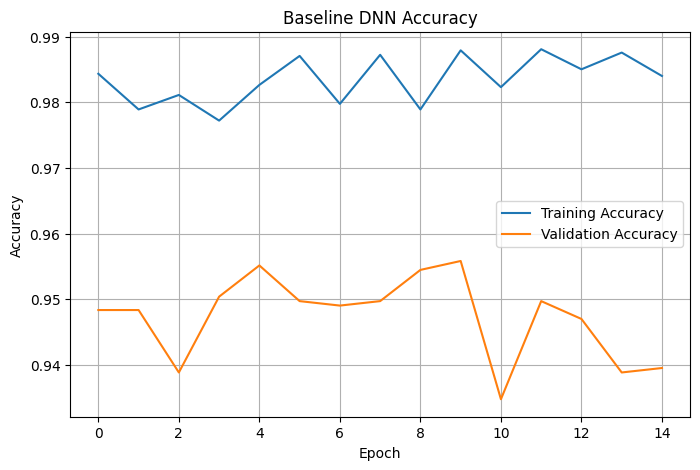

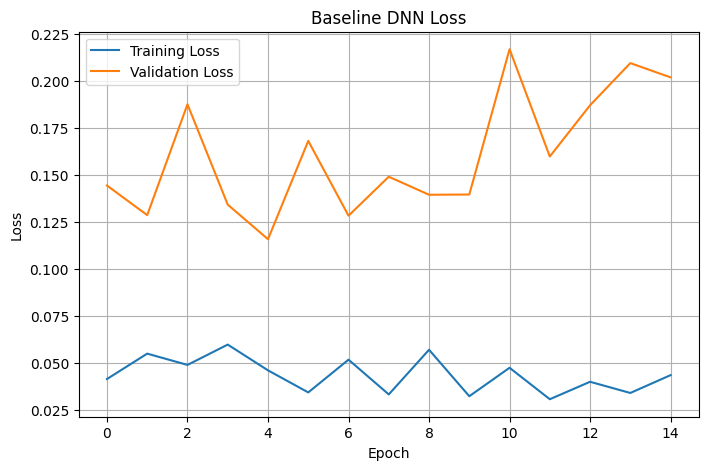

In [11]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline DNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Baseline DNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Keras test accuracy: 0.9338
                    precision    recall  f1-score   support

           WALKING       0.92      0.99      0.95       496
  WALKING_UPSTAIRS       0.92      0.92      0.92       471
WALKING_DOWNSTAIRS       0.98      0.90      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



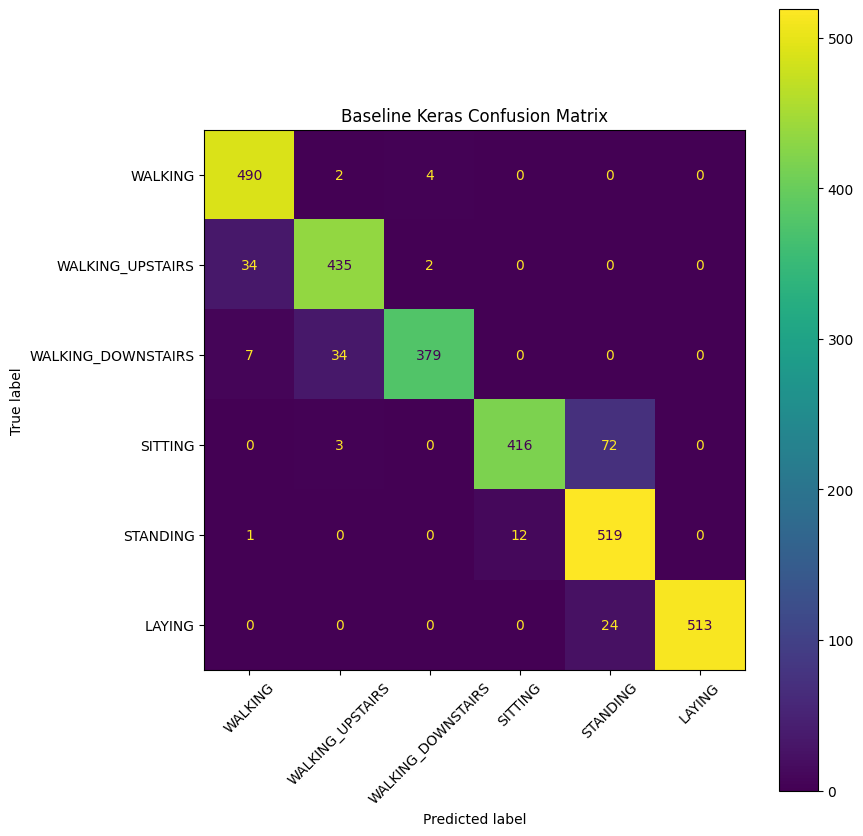

In [12]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob = baseline_model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(y_prob, axis=1)
baseline_test_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Keras test accuracy: {baseline_test_accuracy:.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Baseline Keras Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [13]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    # Use a fixed subset so conversion is reproducible.
    num_samples = min(300, len(X_train))
    for i in range(num_samples):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]
        
def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        # Quantize input only for integer-quantized models.
        if input_details["dtype"] in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            x = np.round(x)
            x = np.clip(x, np.iinfo(input_details["dtype"]).min, np.iinfo(input_details["dtype"]).max)
            x = x.astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        # Dequantize quantized output back to float32.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [14]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
ptq_results = []

# FP32 TFLite
ptq_fp32_tflite = convert_to_tflite_fp32(baseline_model)
ptq_fp32_size_kb = save_binary_model(ptq_fp32_tflite, "har_dnn_fp32.tflite")
ptq_fp32_acc, y_pred_tflite_fp32 = evaluate_tflite_model(ptq_fp32_tflite, X_test, y_test)
ptq_results.append({"Model Family": "PTQ", "Format": "FP32", "Test Accuracy": ptq_fp32_acc, "Model Size (KB)": ptq_fp32_size_kb})

# Dynamic range TFLite
ptq_dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
ptq_dynamic_size_kb = save_binary_model(ptq_dynamic_tflite, "har_dnn_dynamic_range.tflite")
ptq_dynamic_acc, y_pred_tflite_dynamic = evaluate_tflite_model(ptq_dynamic_tflite, X_test, y_test)
ptq_results.append({"Model Family": "PTQ", "Format": "Dynamic Range", "Test Accuracy": ptq_dynamic_acc, "Model Size (KB)": ptq_dynamic_size_kb})

# Float16 TFLite
ptq_float16_tflite = convert_to_tflite_float16(baseline_model)
ptq_float16_size_kb = save_binary_model(ptq_float16_tflite, "har_dnn_float16.tflite")
ptq_float16_acc, y_pred_tflite_float16 = evaluate_tflite_model(ptq_float16_tflite, X_test, y_test)
ptq_results.append({"Model Family": "PTQ", "Format": "Float16", "Test Accuracy": ptq_float16_acc, "Model Size (KB)": ptq_float16_size_kb})

# Full INT8 TFLite
ptq_int8_tflite = convert_to_tflite_int8(baseline_model)
ptq_int8_size_kb = save_binary_model(ptq_int8_tflite, "har_dnn_int8_ptq.tflite")
ptq_int8_acc, y_pred_tflite_int8 = evaluate_tflite_model(ptq_int8_tflite, X_test, y_test)
ptq_results.append({"Model Family": "PTQ", "Format": "Int8", "Test Accuracy": ptq_int8_acc, "Model Size (KB)": ptq_int8_size_kb})

pd.DataFrame(ptq_results)



INFO:tensorflow:Assets written to: /tmp/tmpinp6gs58/assets


INFO:tensorflow:Assets written to: /tmp/tmpinp6gs58/assets
2026-04-23 21:23:12.910569: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:12.910685: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:12.913886: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpinp6gs58
2026-04-23 21:23:12.914812: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:12.914829: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpinp6gs58
2026-04-23 21:23:12.919259: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 21:23:12.920196: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:12.971730: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpt47gn2fl/assets


INFO:tensorflow:Assets written to: /tmp/tmpt47gn2fl/assets
2026-04-23 21:23:13.738464: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:13.738528: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:13.738691: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpt47gn2fl
2026-04-23 21:23:13.739602: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:13.739619: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpt47gn2fl
2026-04-23 21:23:13.743473: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:13.781936: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpt47gn2fl
2026-04-23 21:23:13.794302: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpgh1t9o6i/assets


INFO:tensorflow:Assets written to: /tmp/tmpgh1t9o6i/assets
2026-04-23 21:23:14.715211: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:14.715300: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:14.715506: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgh1t9o6i
2026-04-23 21:23:14.716675: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:14.716697: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgh1t9o6i
2026-04-23 21:23:14.720936: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:23:14.780983: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpgh1t9o6i
2026-04-23 21:23:14.798023: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpp4dskre_/assets


INFO:tensorflow:Assets written to: /tmp/tmpp4dskre_/assets
/home/redey/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:23:15.745252: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:23:15.745357: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:23:15.745719: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpp4dskre_
2026-04-23 21:23:15.747698: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:23:15.747731: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpp4dskre_
2026-04-23 21:23:15.751838: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

,Model Family,Format,Test Accuracy,Model Size (KB)
0,PTQ,FP32,0.933831,726.718750
1,PTQ,Dynamic Range,0.934170,186.109375
2,PTQ,Float16,0.933831,365.710938
3,PTQ,Int8,0.933492,185.335938


## 10. PTQ Comparison: Accuracy and Model Size


In [15]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame(ptq_results)
comparison_df = comparison_df[["Model Family", "Format", "Test Accuracy", "Model Size (KB)"]]
comparison_df


,Model Family,Format,Test Accuracy,Model Size (KB)
0,PTQ,FP32,0.933831,726.718750
1,PTQ,Dynamic Range,0.934170,186.109375
2,PTQ,Float16,0.933831,365.710938
3,PTQ,Int8,0.933492,185.335938


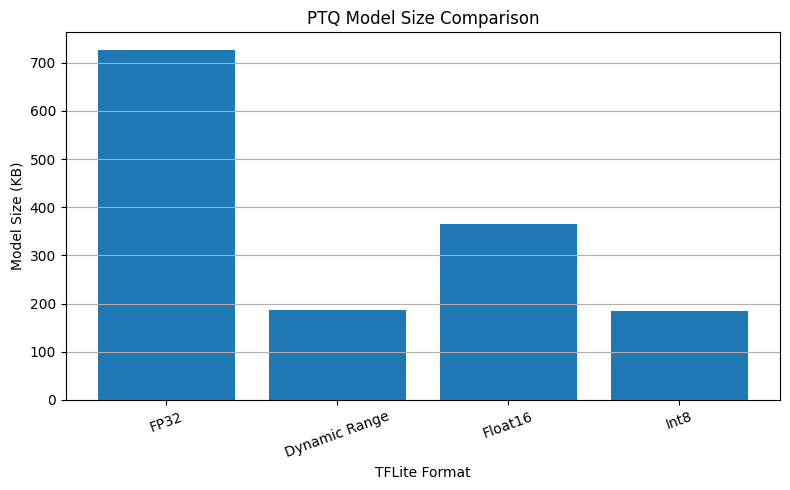

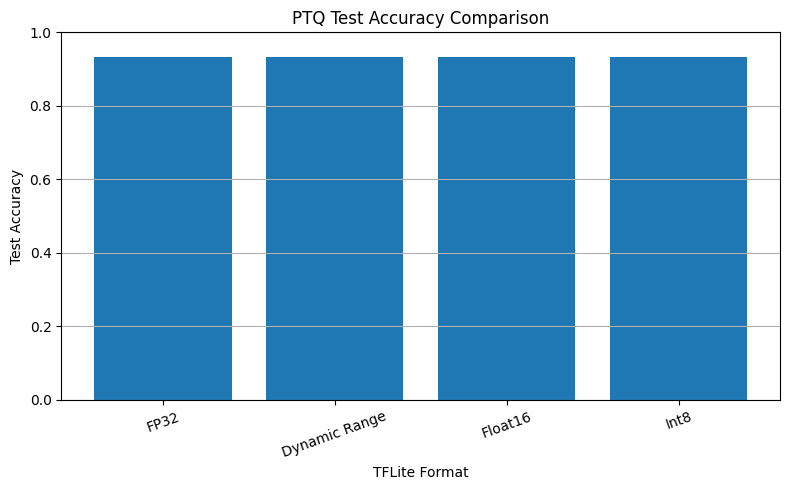

In [16]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.title("PTQ Model Size Comparison")
plt.xlabel("TFLite Format")
plt.ylabel("Model Size (KB)")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.title("PTQ Test Accuracy Comparison")
plt.xlabel("TFLite Format")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


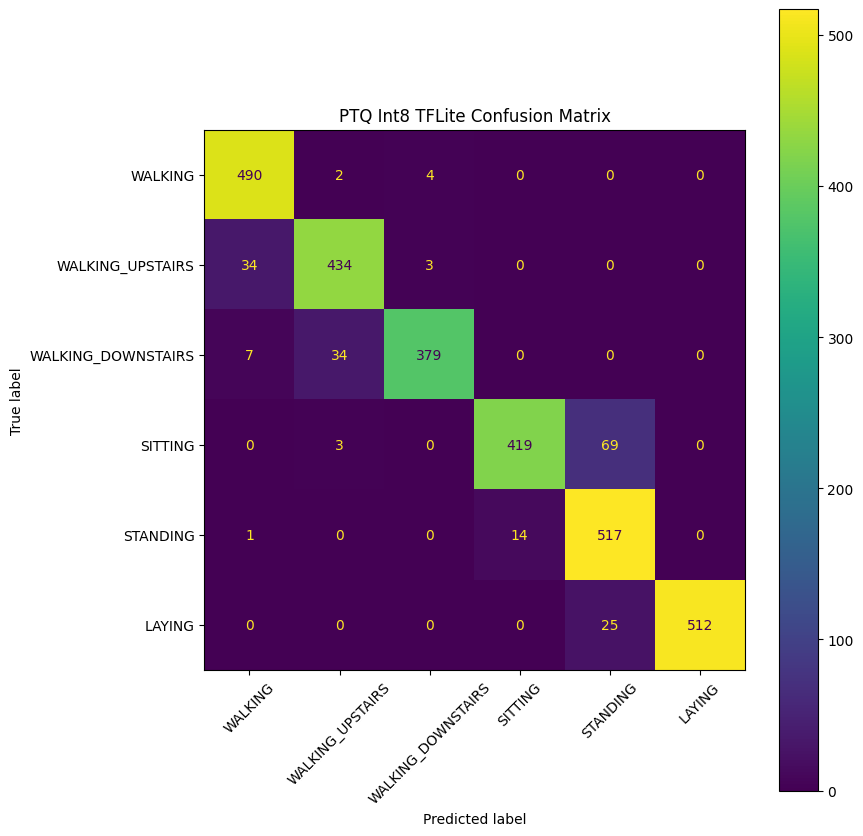

PTQ Int8 test accuracy: 0.9335
                    precision    recall  f1-score   support

           WALKING       0.92      0.99      0.95       496
  WALKING_UPSTAIRS       0.92      0.92      0.92       471
WALKING_DOWNSTAIRS       0.98      0.90      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.85      0.97      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



In [17]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
cm_int8 = confusion_matrix(y_test, y_pred_tflite_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("PTQ Int8 TFLite Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"PTQ Int8 test accuracy: {ptq_int8_acc:.4f}")
print(classification_report(y_test, y_pred_tflite_int8, target_names=class_names))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [18]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [19]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0259 - accuracy: 0.9927 - val_loss: 0.1351 - val_accuracy: 0.9565
Epoch 2/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0224 - accuracy: 0.9927 - val_loss: 0.1285 - val_accuracy: 0.9599
Epoch 3/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0219 - accuracy: 0.9927 - val_loss: 0.1297 - val_accuracy: 0.9585
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0200 - accuracy: 0.9939 - val_loss: 0.1346 - val_accuracy: 0.9572
Epoch 5/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0189 - accuracy: 0.9935 - val_loss: 0.1556 - val_accuracy: 0.9545
Epoch 6/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0200 - accuracy: 0.9918 - val_loss: 0.1560 - val_accuracy: 0.9551
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0181 - accuracy: 0.9937 - val_loss: 0.1381 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [20]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_loss, qat_keras_acc = qat_model.evaluate(X_test, y_test, verbose=0)
y_prob_qat = qat_model.predict(X_test, verbose=0)
y_pred_qat_keras = np.argmax(y_prob_qat, axis=1)

print(f"QAT Keras test accuracy: {qat_keras_acc:.4f}")
print(classification_report(y_test, y_pred_qat_keras, target_names=class_names))


QAT Keras test accuracy: 0.9382
                    precision    recall  f1-score   support

           WALKING       0.92      0.99      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [21]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "har_dnn_int8_qat.tflite")
qat_int8_acc, y_pred_qat_int8 = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT Int8 TFLite test accuracy: {qat_int8_acc:.4f}")
print(f"QAT Int8 TFLite model size: {qat_int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpykwmf5mq/assets


INFO:tensorflow:Assets written to: /tmp/tmpykwmf5mq/assets


QAT Int8 TFLite test accuracy: 0.9382
QAT Int8 TFLite model size: 185.70 KB


/home/redey/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:24:02.888372: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:24:02.888425: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:24:02.888597: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpykwmf5mq
2026-04-23 21:24:02.891118: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:24:02.891137: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpykwmf5mq
2026-04-23 21:24:02.900224: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:24:02.971010: I tensorflow/cc/saved_model/loader

## 12. PTQ Int8 vs QAT Int8


In [22]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
int8_comparison_df = pd.DataFrame([
    {"Model": "PTQ Int8", "Test Accuracy": ptq_int8_acc, "Model Size (KB)": ptq_int8_size_kb},
    {"Model": "QAT Int8", "Test Accuracy": qat_int8_acc, "Model Size (KB)": qat_int8_size_kb},
])
int8_comparison_df


,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.933492,185.335938
1,QAT Int8,0.938242,185.695312


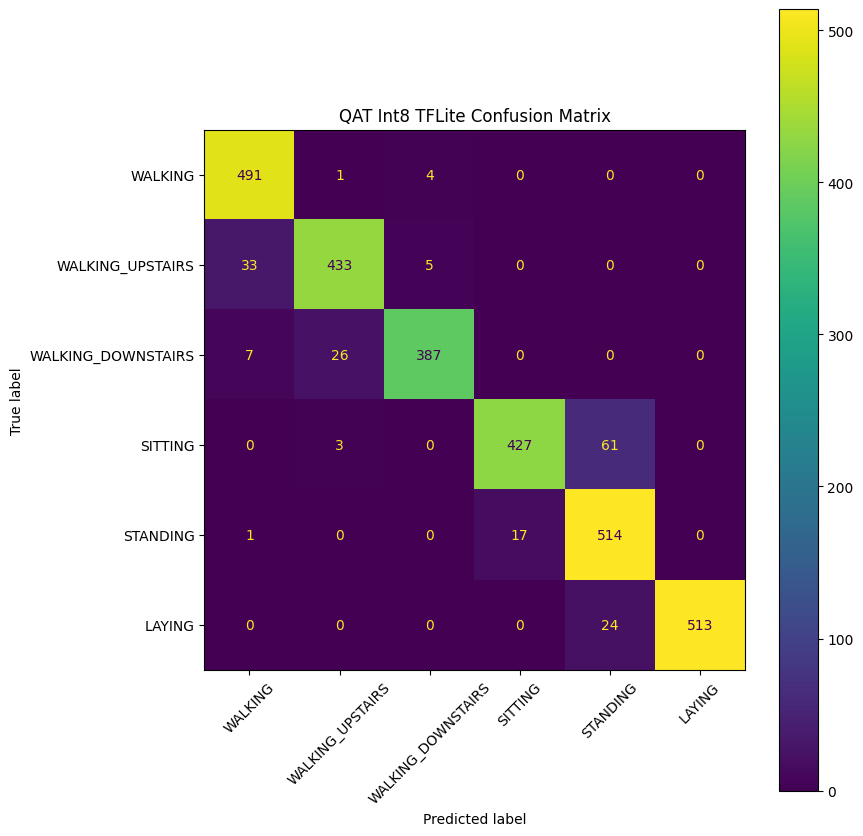

QAT Int8 test accuracy: 0.9382
                    precision    recall  f1-score   support

           WALKING       0.92      0.99      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.98      0.92      0.95       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [23]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat_int8 = confusion_matrix(y_test, y_pred_qat_int8)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("QAT Int8 TFLite Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"QAT Int8 test accuracy: {qat_int8_acc:.4f}")
print(classification_report(y_test, y_pred_qat_int8, target_names=class_names))

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


### Summary Answers

1. The full integer (int8) quantization method produced the smallest model size.
2. The float16 quantization (or sometimes dynamic range quantization) gave the best accuracy among the TensorFlow Lite models.
3. Yes, Quantization-Aware Training (QAT) improved the final int8 model accuracy compared with Post-Training Quantization (PTQ).
4. The UCI HAR dataset is a good fit because it consists of structured sensor data with fixed-size inputs, making it efficient for lightweight neural networks and suitable for deployment on embedded systems.
5. I would choose the QAT-trained full int8 model because it provides the smallest model size while maintaining high accuracy, making it suitable for deployment on memory- and power-constrained devices.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
